## Phase 5 - IoT Simulation & Live Stream Monitoring

**Goal:** Replicate real-world deployment - train on historical data,
freeze the model, then feed unseen beats one at a time as if arriving
live from a wearable sensor.

This is the phase where VitalWatch stops being a notebook
and starts behaving like a deployed clinical system.

In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

C:\Users\Manoj\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# Load record
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

In [3]:
ecg_signal = record.p_signal[:, 0]
fs = record.fs
ann_samples = annotation.sample
ann_symbols = annotation.symbol

In [4]:
# Rebuild all features
rr_intervals = np.diff(ann_samples)
rr_ms = (rr_intervals / fs) * 1000
heart_rate = 60000 / rr_ms
rr_diff = np.append(0, np.diff(rr_ms))
rolling_mean_rr = pd.Series(rr_ms).rolling(window=5, min_periods=1).mean().values
rolling_std_rr = pd.Series(rr_ms).rolling(window=5, min_periods=1).std().fillna(0).values
relative_rr = rr_ms / rolling_mean_rr

feature_df = pd.DataFrame({
    'sample': ann_samples[1:],
    'symbol': ann_symbols[1:],
    'rr_interval': rr_ms,
    'heart_rate': heart_rate,
    'rr_diff': rr_diff,
    'rolling_mean_rr': rolling_mean_rr,
    'rolling_std_rr': rolling_std_rr,
    'relative_rr': relative_rr,
})

print(f"Pipeline ready - {len(feature_df)} beats loaded")

Pipeline ready - 2273 beats loaded


### Training the model 
We will be training the model on the first 80% of beats. When taking into production, the model would be pretrained on historical data which helps the model in familiarizing the data that is fed later on in the real world.

In [5]:
# Split - train on first 80%, simulate live stream on last 20%
split_idx = int(len(feature_df) * 0.8)

In [6]:
train_df = feature_df.iloc[:split_idx]
stream_df = feature_df.iloc[split_idx:].reset_index(drop=True)

In [7]:
features = ['rr_interval', 'heart_rate', 'rr_diff', 'rolling_mean_rr', 'rolling_std_rr', 'relative_rr']

In [8]:
X_train = train_df[features].values
X_stream = stream_df[features].values

In [9]:
# Scale using training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_stream_scaled = scaler.transform(X_stream)

### Why fit_transform on train, transform only on stream?

StandardScaler calculates mean and std from whatever data you fit it on.

If we fit on stream data - we are using future data to define the
scaling parameters. In production, future data doesn't exist yet.
The model would appear to work in the notebook but fail in the
real world because the scaling baseline would shift with every
new patient.

This is called **data leakage** - and it is one of the most common
reasons ML models collapse between development and production.
Fit once on training data. Apply everywhere else.

In [10]:
# Train on historical data
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.015,
    random_state=42
)
iso_forest.fit(X_train_scaled)

print(f"Model trained on {len(train_df)} beats")
print(f"Simulating live stream on {len(stream_df)} beats")

Model trained on 1818 beats
Simulating live stream on 455 beats


### Live Stream Simulation

Each beat is fed into the model individually - one at a time.
This mirrors exactly how a wearable device delivers data.
The model has no knowledge of what comes next.

We print every anomaly immediately and every 10th normal beat
to keep the output readable without hiding anything important.

What we're watching for:
- **True Positives** - flagged AND genuinely abnormal
- **False Positives** - flagged BUT actually normal
- **False Negatives** - missed AND genuinely abnormal (silent danger)

In [11]:
print("--- Streaming Live ---")

print(f"{'Beat':>6} {'Sample':>8} {'Heart Rate':>12} "
      f"{'RR Interval':>13} {'Status':>10}")

alerts = []
normal_count = 0
anomaly_count = 0

for i in range(len(stream_df)):
    row = stream_df.iloc[i]
    beat_features = X_stream_scaled[i].reshape(1, -1)
    prediction = iso_forest.predict(beat_features)[0]

    is_anomaly = prediction == -1
    status = "ANOMALY" if is_anomaly else "Normal"
    flag = " <<<" if is_anomaly else ""

    # Print every 10th normal beat to keep output readable
    # Always print anomalies
    if is_anomaly or i % 10 == 0:
        print(f"{i+1:>5} {int(row['sample']):>8} "
              f"{row['heart_rate']:>9.1f} "
              f"{row['rr_interval']:>9.1f} "
              f"{status:>12}{flag}")

    if is_anomaly:
        anomaly_count += 1
        alerts.append({
            'beat_num':    i + 1,
            'sample':      int(row['sample']),
            'heart_rate':  round(row['heart_rate'], 1),
            'rr_interval': round(row['rr_interval'], 1),
            'rr_diff':     round(row['rr_diff'], 1),
            'true_label':  row['symbol']
        })
    else:
        normal_count += 1

print(f"\nStream complete.")
print(f"Total beats monitored: {len(stream_df)}")
print(f"Normal: {normal_count}")
print(f"Anomalies flagged: {anomaly_count}")

--- Streaming Live ---
  Beat   Sample   Heart Rate   RR Interval     Status
    1   520982     100.9     594.4       Normal
    2   521342      60.0    1000.0      ANOMALY <<<
   11   523999      74.2     808.3       Normal
   21   526941      73.2     819.4       Normal
   31   529897      72.5     827.8       Normal
   41   532828      76.1     788.9       Normal
   51   535768      69.9     858.3       Normal
   61   538707      75.5     794.4       Normal
   71   541616      76.6     783.3       Normal
   81   544590      70.8     847.2       Normal
   89   546792     111.9     536.1      ANOMALY <<<
   90   547199      53.1    1130.6      ANOMALY <<<
   91   547482      76.3     786.1       Normal
  101   550348      77.7     772.2       Normal
  111   553282      70.1     855.6       Normal
  121   556203      74.7     802.8       Normal
  131   559102      74.7     802.8       Normal
  141   562019      75.3     797.2       Normal
  151   564883      76.6     783.3       Normal

In [12]:
#Print the alert logs
if alerts:
    alert_df = pd.DataFrame(alerts)
    print(f"\n{'#':<6} {'Sample':<10} {'HR':<10} "
          f"{'RR(ms)':<10} {'RR Diff':<10} {'True Label':<10}")
    print("-"*60)
    for _, row in alert_df.iterrows():
        label_display = "REAL" if row['true_label'] != 'N' else "False"
        print(f"{int(row['beat_num']):<6} "
              f"{int(row['sample']):<10} "
              f"{row['heart_rate']:<10} "
              f"{row['rr_interval']:<10} "
              f"{row['rr_diff']:<10} "
              f"{label_display:<10}")

    true_pos = alert_df[alert_df['true_label'] != 'N']
    false_pos = alert_df[alert_df['true_label'] == 'N']

    print(f"\nTrue positives  (real anomalies caught): {len(true_pos)}")
    print(f"False positives (normal beats flagged):  {len(false_pos)}")
    print(f"Precision: {len(true_pos)/len(alert_df)*100:.1f}%")
else:
    print("No anomalies detected.")


#      Sample     HR         RR(ms)     RR Diff    True Label
------------------------------------------------------------
2      521342     60.0       1000.0     405.6      False     
89     546792     111.9      536.1      -277.8     REAL      
90     547199     53.1       1130.6     594.4      False     
157    566615     60.7       988.9      383.3      False     
160    567379     111.3      538.9      -255.6     REAL      
161    567721     63.2       950.0      411.1      False     
185    574786     60.5       991.7      336.1      False     
379    629171     113.7      527.8      -286.1     REAL      

True positives  (real anomalies caught): 3
False positives (normal beats flagged):  5
Precision: 37.5%


### Key Insights - Stream Results

8 beats flagged across 455 monitored beats - 1.76% flag rate,
closely matching our contamination prior of 1.5%.

3 of 8 flags were genuinely abnormal - 37.5% precision.
5 were false positives - normal beats that looked statistically unusual.

The stream contained fewer abnormal beats than the full record
(the 20% split landed on a relatively calm section of the recording).
This is realistic - anomalies are rare and unevenly distributed.
A monitoring system must stay vigilant during long stretches of normal
activity and respond instantly when patterns shift.

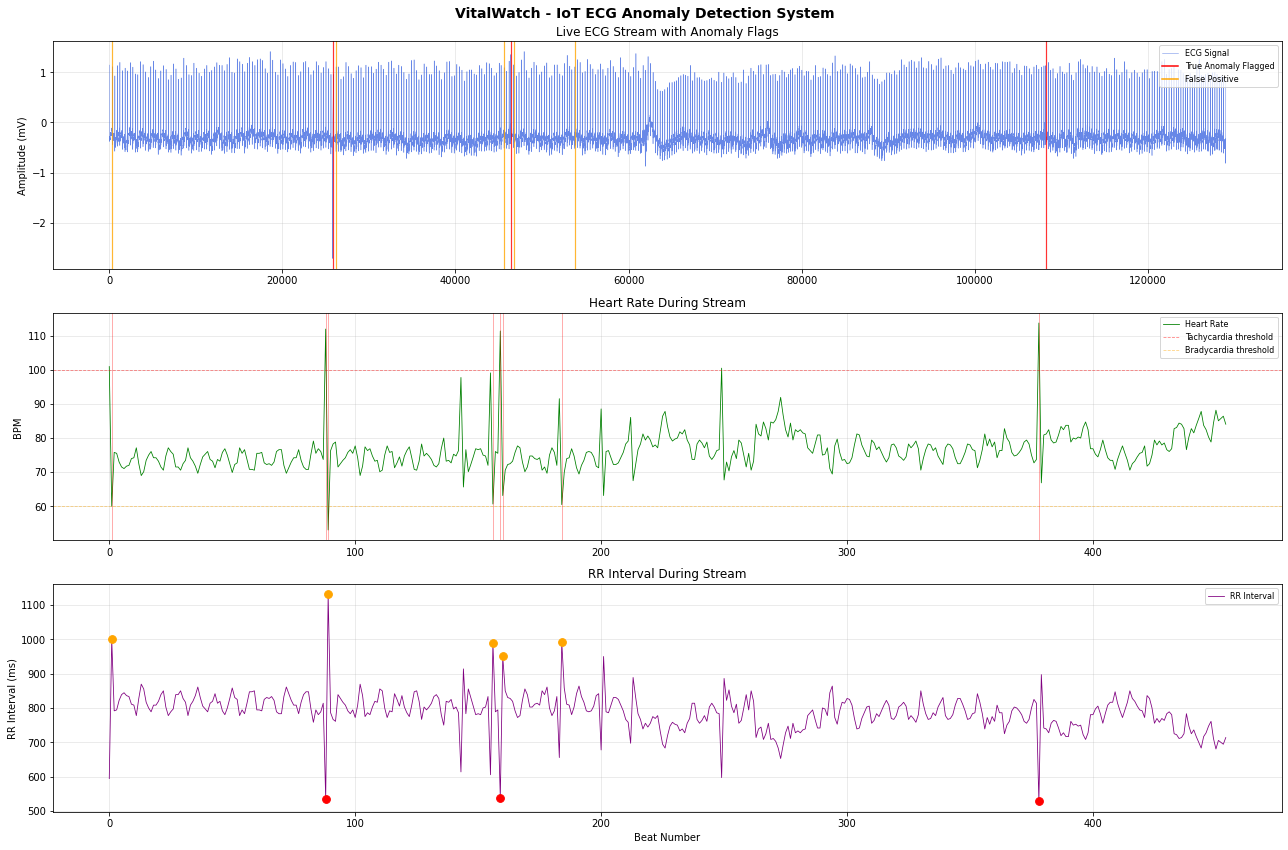

Final visualisation saved as vitalwatch_final.png


In [13]:
# Full project visualisation - the complete VitalWatch story
fig, axes = plt.subplots(3, 1, figsize=(18, 12))
fig.suptitle('VitalWatch - IoT ECG Anomaly Detection System', fontsize=14, fontweight='bold', y=0.98)

# Plot 1 - Raw ECG with all flagged beats
stream_start = int(stream_df.iloc[0]['sample'])
stream_end = int(stream_df.iloc[-1]['sample'])
ecg_stream = ecg_signal[stream_start:stream_end]

axes[0].plot(ecg_stream, color='royalblue', linewidth=0.5, alpha=0.8, label='ECG Signal')
axes[0].set_title('Live ECG Stream with Anomaly Flags')
axes[0].set_ylabel('Amplitude (mV)')

for alert in alerts:
    rel_sample = alert['sample'] - stream_start
    if 0 <= rel_sample < len(ecg_stream):
        color = 'red' if alert['true_label'] != 'N' else 'orange'
        axes[0].axvline(x=rel_sample, color=color, alpha=0.8, linewidth=1.2)

axes[0].plot([], [], color='red', label='True Anomaly Flagged')
axes[0].plot([], [], color='orange', label='False Positive')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot 2 - Heart rate over stream
axes[1].plot(stream_df['heart_rate'].values, color='green', linewidth=0.8, label='Heart Rate')
axes[1].axhline(y=100, color='red', linestyle='--', alpha=0.5, linewidth=0.8, label='Tachycardia threshold')
axes[1].axhline(y=60, color='orange', linestyle='--', alpha=0.5, linewidth=0.8, label='Bradycardia threshold')

for alert in alerts:
    axes[1].axvline(x=alert['beat_num']-1, color='red', alpha=0.4, linewidth=0.8)

axes[1].set_title('Heart Rate During Stream')
axes[1].set_ylabel('BPM')
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(True, alpha=0.3)

# Plot 3 — RR interval with anomaly markers
axes[2].plot(stream_df['rr_interval'].values, color='purple', linewidth=0.8, label='RR Interval')

for alert in alerts:
    color = 'red' if alert['true_label'] != 'N' else 'orange'
    axes[2].scatter(alert['beat_num']-1, alert['rr_interval'], color=color, s=60, zorder=5)

axes[2].set_title('RR Interval During Stream')
axes[2].set_ylabel('RR Interval (ms)')
axes[2].set_xlabel('Beat Number')
axes[2].legend(loc='upper right', fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('vitalwatch_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("Final visualisation saved as vitalwatch_final.png")

### Phase 5 Complete - VitalWatch is Live

The model was trained on 1818 historical beats, frozen,
and deployed to watch 455 incoming beats it had never seen.

It flagged 8 beats. 3 were real. The alarm worked.

**Full project summary:**
- Phase 1: Loaded and understood real clinical ECG data
- Phase 2: Engineered 6 features from raw signal
- Phase 3: Baseline Isolation Forest - 44.1% detection
- Phase 4: Enhanced model - 52.9% detection
- Phase 4b: DBSCAN comparison - proved model selection matters
- Phase 5: Live stream simulation - VitalWatch deployed

The gap between 52.9% and 100% is not a failure.
It is the honest boundary of what unsupervised ML can do
on subtle cardiac rhythm deviations with limited data.
That gap is where future work lives - more features,
more patients, and eventually an Autoencoder.

VitalWatch is not finished. It is version one.